# Phase 2 — Analyse Statistique Descriptive

**Input** : `laptop_phase1.csv`  
**Output** : `laptop_phase2.csv` + `stats_summary.json` + visualisations

Étapes :
1. Chargement des données
2. Stats globales
3. Stats par plateforme
4. Stats par marque
5. Stats par gamme de prix (Q1/Q3)
6. Analyse RAM
7. Visualisations
8. Export JSON/CSV pour Django

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json, os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

INPUT_PATH = '../inputs/laptop_phase1.csv'
OUTPUT_DIR = '../outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('✅ Setup terminé')

✅ Setup terminé


## 1. Chargement des données

In [2]:
df = pd.read_csv(INPUT_PATH)

print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
print(f'Plateformes : {df["platform"].unique()}')
print(f'Marques : {df["brand"].nunique()} uniques')
print(f'ram_gb renseignée     : {df["ram_gb"].notna().sum()}/{len(df)} ({df["ram_gb"].notna().mean()*100:.0f}%)')
print(f'storage_gb renseignée : {df["storage_gb"].notna().sum()}/{len(df)} ({df["storage_gb"].notna().mean()*100:.0f}%)')
df.head(3)

Shape : (50, 12)
Colonnes : ['title', 'brand', 'price', 'price_usd', 'currency', 'platform', 'ram_gb', 'storage_gb', 'category', 'search_query', 'url', 'scraped_date']
Plateformes : <StringArray>
['jumia', 'aliexpress']
Length: 2, dtype: str
Marques : 9 uniques
ram_gb renseignée     : 38/50 (76%)
storage_gb renseignée : 33/50 (66%)


,title,brand,price,price_usd,currency,platform,ram_gb,storage_gb,category,search_query,url,scraped_date
0,"Hp Laptop 15-FC0075k - Ecran FHD 15,6""- Ryzen5...",HP,5799.00,579.90,MAD,jumia,8.0,512.0,electronics,laptop,https://www.jumia.ma/hp-laptop-15-fc0075k-ecra...,2026-05-13
1,Lenovo ThinkPad X13 Yoga Gen 1 Convertible Lap...,Lenovo,4099.00,409.90,MAD,jumia,16.0,512.0,electronics,laptop,https://www.jumia.ma/lenovo-thinkpad-x13-yoga-...,2026-05-13
2,2025 MSI Stealth 18 HX AI Gaming Laptop 18 Inc...,MSI,39218.93,3921.89,MAD,aliexpress,64.0,2048.0,electronics,laptop,https://www.aliexpress.com/item/10050116276281...,2026-05-13


## 2. Stats globales

In [3]:
def compute_stats(series, label='global'):
    return {
        'groupe':   label,
        'count':    int(series.count()),
        'min':      round(float(series.min()), 2),
        'max':      round(float(series.max()), 2),
        'mean':     round(float(series.mean()), 2),
        'median':   round(float(series.median()), 2),
        'std':      round(float(series.std()), 2),
        'q1':       round(float(series.quantile(0.25)), 2),
        'q3':       round(float(series.quantile(0.75)), 2),
        'iqr':      round(float(series.quantile(0.75) - series.quantile(0.25)), 2),
        'skewness': round(float(series.skew()), 4),
    }

stats_global = compute_stats(df['price'], label='global')

print('=== STATISTIQUES GLOBALES (prix en MAD) ===')
for k, v in stats_global.items():
    print(f'  {k:<12} : {v}')

=== STATISTIQUES GLOBALES (prix en MAD) ===
  groupe       : global
  count        : 50
  min          : 2602.93
  max          : 45362.04
  mean         : 13708.18
  median       : 12624.83
  std          : 9615.94
  q1           : 6603.82
  q3           : 17308.22
  iqr          : 10704.4
  skewness     : 1.492


In [4]:
print(df['price'].describe().round(2))

count       50.00
mean     13708.18
std       9615.94
min       2602.93
25%       6603.82
50%      12624.84
75%      17308.22
max      45362.04
Name: price, dtype: float64


## 3. Stats par plateforme

In [5]:
stats_platform = []
for platform, group in df.groupby('platform'):
    stats_platform.append(compute_stats(group['price'], label=platform))

df_stats_platform = pd.DataFrame(stats_platform).set_index('groupe')
print('=== STATS PAR PLATEFORME (MAD) ===')
print(df_stats_platform.to_string())

=== STATS PAR PLATEFORME (MAD) ===
            count      min       max      mean    median      std       q1       q3       iqr  skewness
groupe                                                                                                 
aliexpress     48  2602.93  45362.04  14073.14  13342.42  9642.07  7168.92  17485.8  10316.88    1.4612
jumia           2  4099.00   5799.00   4949.00   4949.00  1202.08  4524.00   5374.0    850.00       NaN


## 4. Stats par marque

In [6]:
brand_counts = df['brand'].value_counts()
brands_to_keep = brand_counts[brand_counts >= 3].index

stats_brand = []
for brand, group in df[df['brand'].isin(brands_to_keep)].groupby('brand'):
    stats_brand.append(compute_stats(group['price'], label=brand))

df_stats_brand = pd.DataFrame(stats_brand).set_index('groupe').sort_values('median', ascending=False)
print('=== STATS PAR MARQUE (MAD) — min. 3 produits ===')
print(df_stats_brand.to_string())

=== STATS PAR MARQUE (MAD) — min. 3 produits ===
        count       min       max      mean    median       std        q1        q3      iqr  skewness
groupe                                                                                                
Honor       5  13751.69  19547.05  16898.15  17047.30   2074.14  16749.50  17395.20   645.70   -0.5809
Acer        5   7421.66  19856.04  13822.31  15684.53   5608.47   8391.73  17757.60  9365.87   -0.3196
Lenovo      6   4099.00  45362.04  18008.23  15640.23  14369.83  10717.78  17583.24  6865.47    1.7229
Xiaomi      8   6914.30  18193.36  12942.48  13763.39   3710.72  11315.24  14552.87  3237.63   -0.4731
Huawei      5   7949.60  22258.02  13222.78  11952.24   5555.33   9822.20  14131.86  4309.66    1.3375
GPD         3   9521.78  18361.21  13246.52  11856.57   4580.70  10689.17  15108.89  4419.72    1.2397
Other      14   2602.93  33571.45   9178.35   5319.07   9935.83   3731.33   7065.43  3334.09    2.0340


## 5. Catégorisation par gamme de prix (règle métier)

Seuils basés sur Q1 / Q3.  
Cette segmentation sera **affinée automatiquement** en Phase 3 par K-Means sur `price` + `ram_gb`.

In [7]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

print(f'Q1 = {Q1:.0f} MAD  →  bas de gamme en-dessous')
print(f'Q3 = {Q3:.0f} MAD  →  haut de gamme au-dessus')

def price_range_label(price):
    if price < Q1:    return 'bas_de_gamme'
    elif price <= Q3: return 'milieu_de_gamme'
    else:             return 'haut_de_gamme'

df['price_range'] = df['price'].apply(price_range_label)

print('\nRépartition par gamme :')
print(df['price_range'].value_counts())

Q1 = 6604 MAD  →  bas de gamme en-dessous
Q3 = 17308 MAD  →  haut de gamme au-dessus

Répartition par gamme :
price_range
milieu_de_gamme    24
bas_de_gamme       13
haut_de_gamme      13
Name: count, dtype: int64


In [8]:
stats_range = []
for rng, group in df.groupby('price_range'):
    stats_range.append(compute_stats(group['price'], label=rng))

df_stats_range = pd.DataFrame(stats_range).set_index('groupe')
print(df_stats_range.to_string())

                 count       min       max      mean    median      std        q1        q3       iqr  skewness
groupe                                                                                                         
bas_de_gamme        13   2602.93   6500.33   4496.08   4322.25  1281.35   3534.36   5496.09   1961.73    0.1727
haut_de_gamme       13  17395.20  45362.04  25900.10  19856.04  9828.15  18215.98  33571.45  15355.47    0.8929
milieu_de_gamme     24   6914.30  17047.30  12094.11  12624.83  3322.77   8950.85  14497.75   5546.90   -0.1617


## 6. Analyse RAM & Stockage

`ram_gb` et `storage_gb` sont extraites depuis les titres (Phase 1). Elles serviront de **features** pour le clustering en Phase 3.

In [9]:
df_ram = df.dropna(subset=['ram_gb'])
print(f'Produits avec RAM connue : {len(df_ram)}/{len(df)} ({len(df_ram)/len(df)*100:.0f}%)')
print()
print('Distribution RAM (Go) :')
print(df_ram['ram_gb'].value_counts().sort_index())
print()
print('=== Stats RAM ===')
print(df_ram['ram_gb'].describe().round(2))
print()
print('Prix médian par niveau de RAM :')
print(df_ram.groupby('ram_gb')['price'].median().sort_index().round(0))
print()
df_storage = df.dropna(subset=['storage_gb'])
print(f'Produits avec Stockage connu : {len(df_storage)}/{len(df)} ({len(df_storage)/len(df)*100:.0f}%)')
print()
print('Distribution Stockage (Go) :')
print(df_storage['storage_gb'].value_counts().sort_index())
print()
print('=== Stats Stockage ===')
print(df_storage['storage_gb'].describe().round(2))
print()
print('Prix médian par niveau de stockage :')
print(df_storage.groupby('storage_gb')['price'].median().sort_index().round(0))

Produits avec RAM connue : 38/50 (76%)

Distribution RAM (Go) :
ram_gb
4.0      1
8.0      2
16.0    16
24.0     2
32.0    14
64.0     3
Name: count, dtype: int64

=== Stats RAM ===
count    38.00
mean     25.37
std      14.30
min       4.00
25%      16.00
50%      20.00
75%      32.00
max      64.00
Name: ram_gb, dtype: float64

Prix médian par niveau de RAM :
ram_gb
4.0      2769.0
8.0     12007.0
16.0     9307.0
24.0    13859.0
32.0    17221.0
64.0    18361.0
Name: price, dtype: float64

Produits avec Stockage connu : 33/50 (66%)

Distribution Stockage (Go) :
storage_gb
128.0      1
512.0     11
1024.0    13
2048.0     8
Name: count, dtype: int64

=== Stats Stockage ===
count      33.00
mean     1074.42
std       612.15
min       128.00
25%       512.00
50%      1024.00
75%      1024.00
max      2048.00
Name: storage_gb, dtype: float64

Prix médian par niveau de stockage :
storage_gb
128.0      4516.0
512.0      8528.0
1024.0    15685.0
2048.0    17878.0
Name: price, dtype: float64


## 7. Visualisations

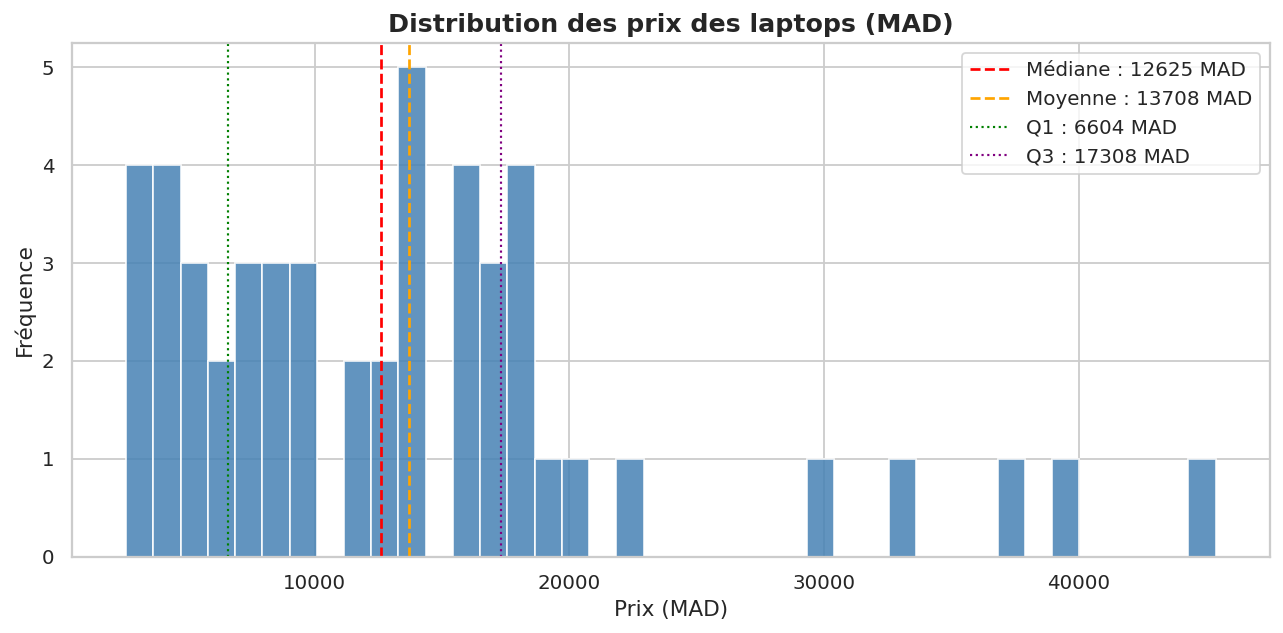

✅ phase2_distribution_prix.png


In [10]:
# 7.1 Distribution des prix
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['price'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['price'].median(), color='red',    linestyle='--', linewidth=1.5, label=f'Médiane : {df["price"].median():.0f} MAD')
ax.axvline(df['price'].mean(),   color='orange', linestyle='--', linewidth=1.5, label=f'Moyenne : {df["price"].mean():.0f} MAD')
ax.axvline(Q1,  color='green',  linestyle=':', linewidth=1.2, label=f'Q1 : {Q1:.0f} MAD')
ax.axvline(Q3,  color='purple', linestyle=':', linewidth=1.2, label=f'Q3 : {Q3:.0f} MAD')
ax.set_title('Distribution des prix des laptops (MAD)', fontsize=14, fontweight='bold')
ax.set_xlabel('Prix (MAD)'); ax.set_ylabel('Fréquence'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase2_distribution_prix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase2_distribution_prix.png')

/tmp/ipykernel_50607/3513254171.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_platform, labels=platforms, patch_artist=True)


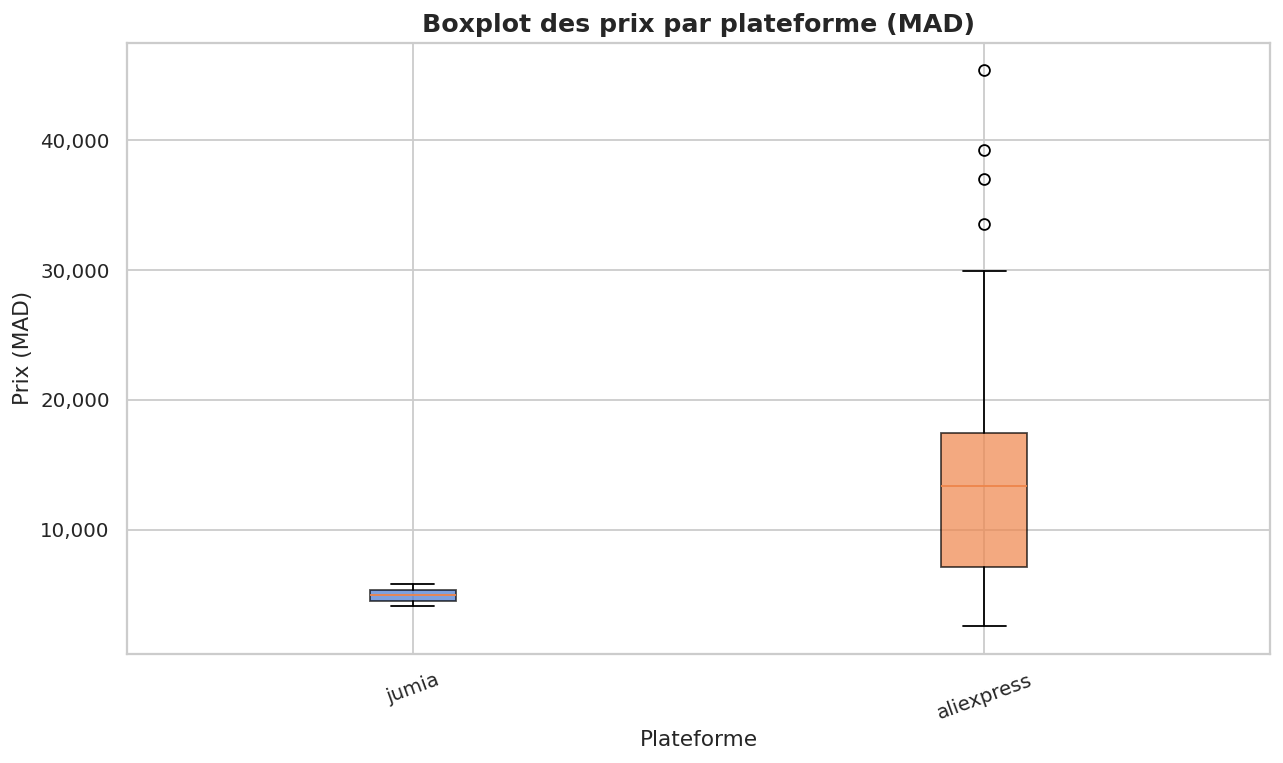

✅ phase2_boxplot_platform.png


In [11]:
# 7.2 Boxplot par plateforme
fig, ax = plt.subplots(figsize=(10, 6))
platforms = df['platform'].unique()
data_by_platform = [df[df['platform'] == p]['price'].values for p in platforms]
bp = ax.boxplot(data_by_platform, labels=platforms, patch_artist=True)
colors = sns.color_palette('muted', len(platforms))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Boxplot des prix par plateforme (MAD)', fontsize=14, fontweight='bold')
ax.set_xlabel('Plateforme'); ax.set_ylabel('Prix (MAD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase2_boxplot_platform.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase2_boxplot_platform.png')

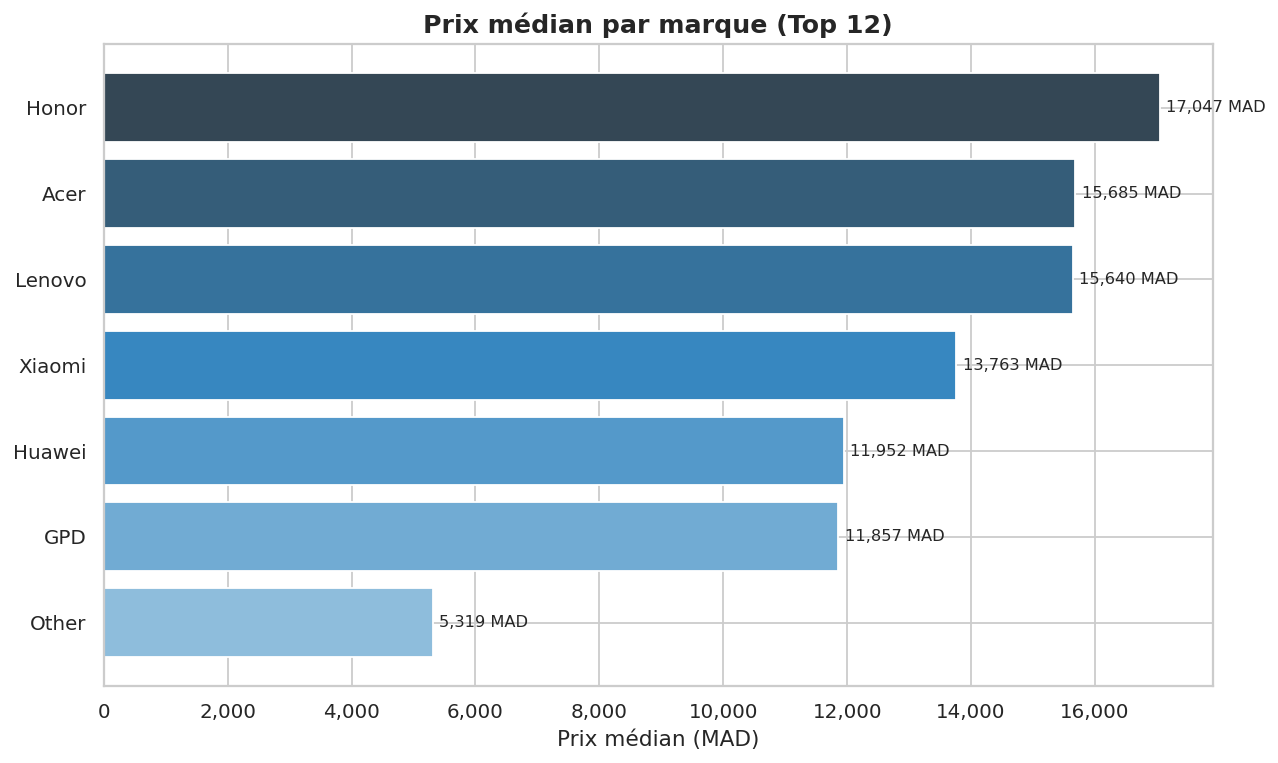

✅ phase2_median_par_marque.png


In [12]:
# 7.3 Prix médian par marque (top 12)
top_brands = df_stats_brand['median'].nlargest(12)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_brands.index[::-1], top_brands.values[::-1],
               color=sns.color_palette('Blues_d', len(top_brands)))
for bar, val in zip(bars, top_brands.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} MAD', va='center', fontsize=9)
ax.set_title('Prix médian par marque (Top 12)', fontsize=14, fontweight='bold')
ax.set_xlabel('Prix médian (MAD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase2_median_par_marque.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase2_median_par_marque.png')

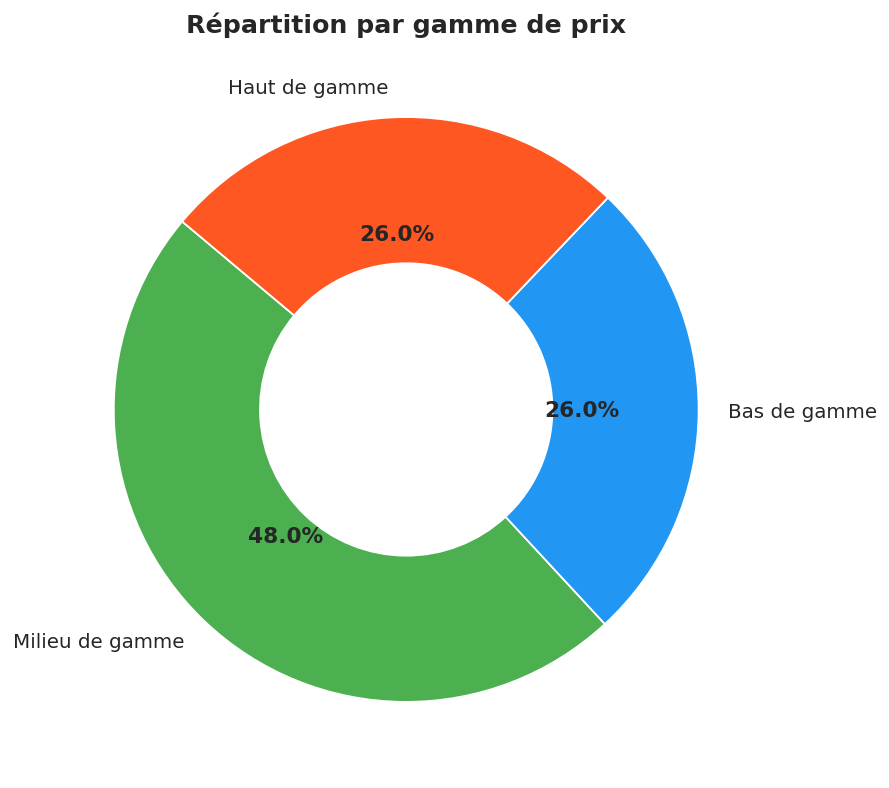

✅ phase2_repartition_gamme.png


In [13]:
# 7.4 Donut par gamme
range_counts = df['price_range'].value_counts()
labels_fr = {'bas_de_gamme': 'Bas de gamme', 'milieu_de_gamme': 'Milieu de gamme', 'haut_de_gamme': 'Haut de gamme'}
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    range_counts.values,
    labels=[labels_fr.get(l, l) for l in range_counts.index],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#2196F3', '#FF5722'],
    startangle=140,
    wedgeprops=dict(width=0.5)
)
for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold')
ax.set_title('Répartition par gamme de prix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase2_repartition_gamme.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase2_repartition_gamme.png')

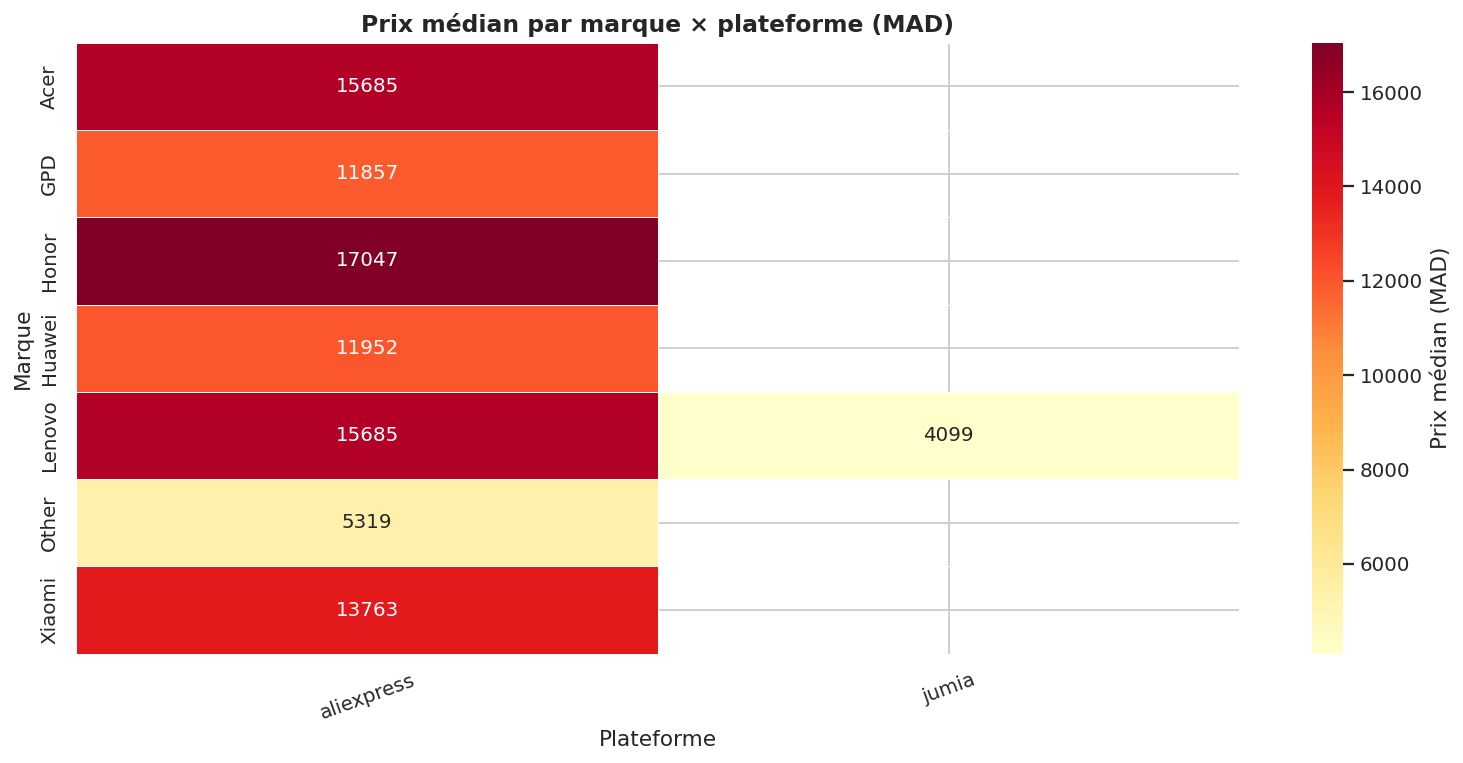

✅ phase2_heatmap_marque_platform.png


In [14]:
# 7.5 Heatmap marque × plateforme
pivot = df[df['brand'].isin(brands_to_keep)].pivot_table(
    values='price', index='brand', columns='platform', aggfunc='median')
fig, ax = plt.subplots(figsize=(12, max(6, len(pivot)*0.4)))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Prix médian (MAD)'})
ax.set_title('Prix médian par marque × plateforme (MAD)', fontsize=13, fontweight='bold')
ax.set_xlabel('Plateforme'); ax.set_ylabel('Marque')
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase2_heatmap_marque_platform.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase2_heatmap_marque_platform.png')

/tmp/ipykernel_50607/260659511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='platform', y='price', palette='muted', inner='quartile', ax=ax)


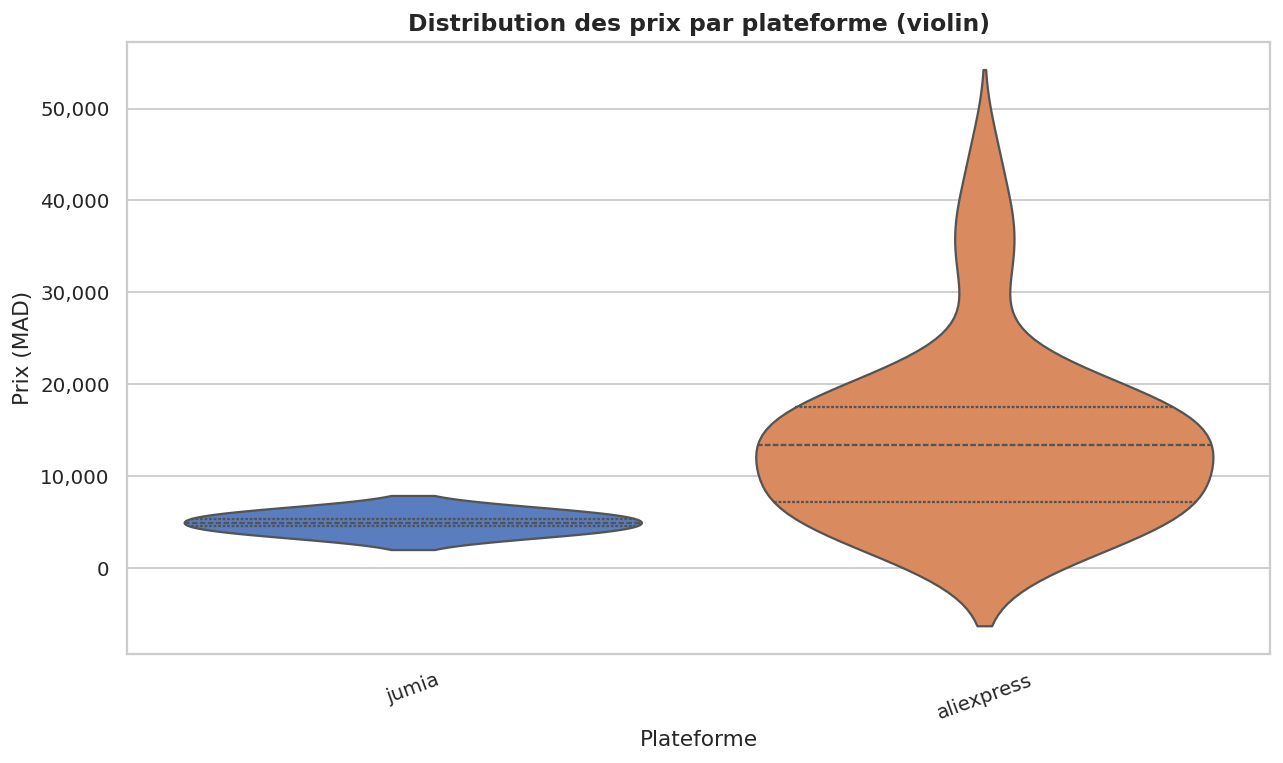

✅ phase2_violin_platform.png


In [15]:
# 7.6 Violin plot par plateforme
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x='platform', y='price', palette='muted', inner='quartile', ax=ax)
ax.set_title('Distribution des prix par plateforme (violin)', fontsize=13, fontweight='bold')
ax.set_xlabel('Plateforme'); ax.set_ylabel('Prix (MAD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase2_violin_platform.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase2_violin_platform.png')

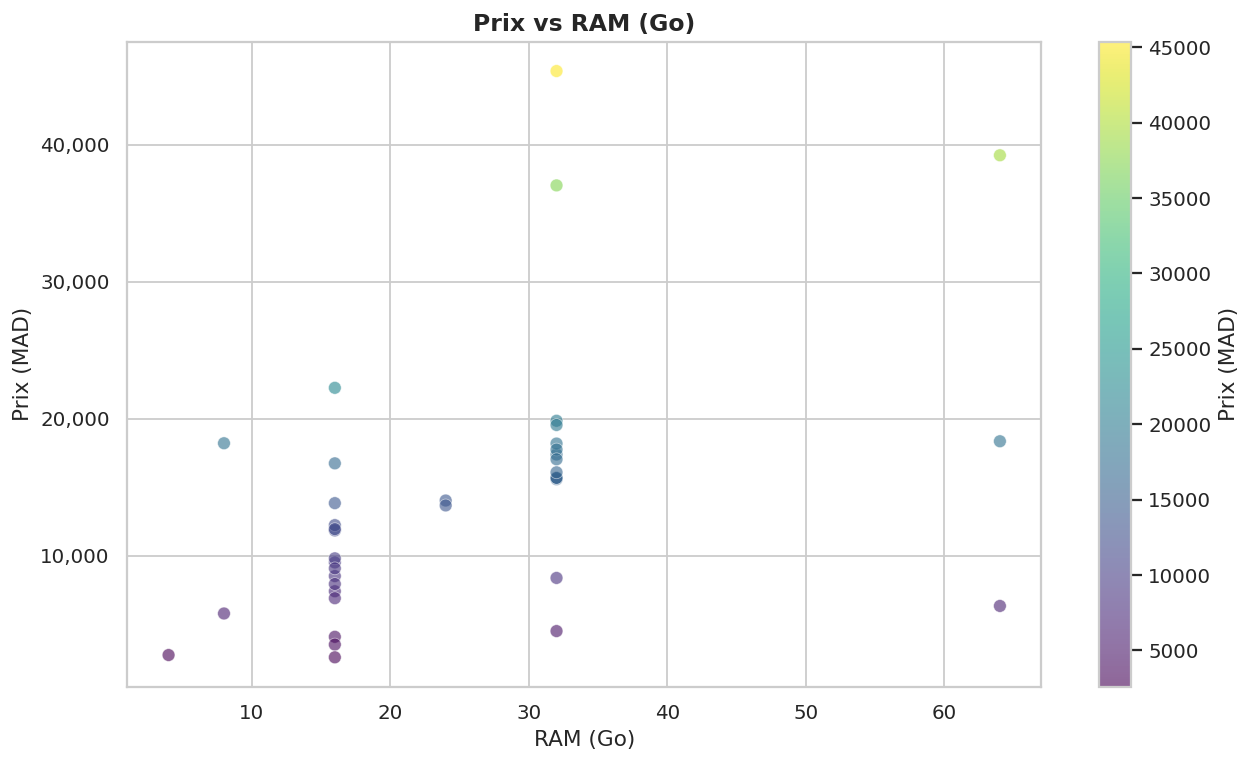

✅ phase2_price_vs_ram.png


In [16]:
# 7.7 Scatter price vs ram_gb
df_ram = df.dropna(subset=['ram_gb'])
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df_ram['ram_gb'], df_ram['price'],
                     c=df_ram['price'], cmap='viridis', alpha=0.6, s=50, edgecolors='white', linewidths=0.4)
plt.colorbar(scatter, ax=ax, label='Prix (MAD)')
ax.set_title('Prix vs RAM (Go)', fontsize=13, fontweight='bold')
ax.set_xlabel('RAM (Go)')
ax.set_ylabel('Prix (MAD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase2_price_vs_ram.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase2_price_vs_ram.png')

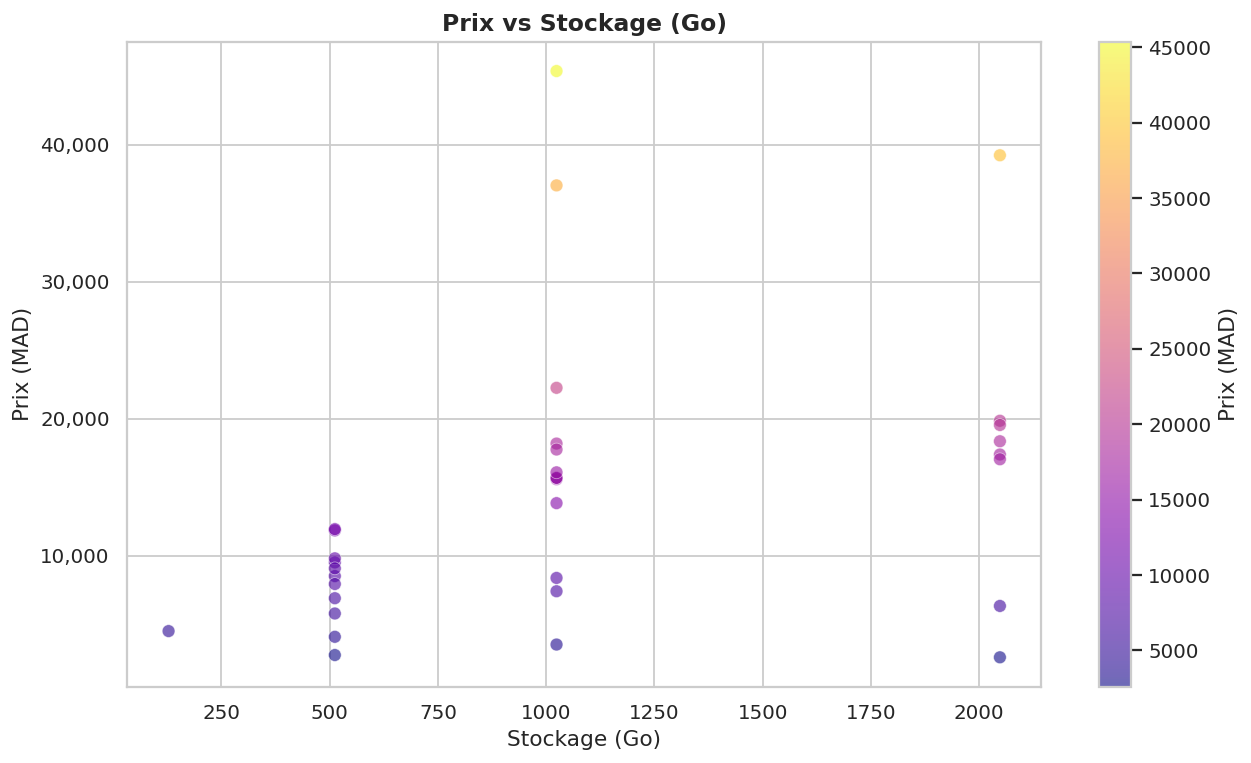

✅ phase2_price_vs_storage.png


In [17]:
# 7.8 Scatter price vs storage_gb
df_storage = df.dropna(subset=['storage_gb'])
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df_storage['storage_gb'], df_storage['price'],
                     c=df_storage['price'], cmap='plasma', alpha=0.6, s=50, edgecolors='white', linewidths=0.4)
plt.colorbar(scatter, ax=ax, label='Prix (MAD)')
ax.set_title('Prix vs Stockage (Go)', fontsize=13, fontweight='bold')
ax.set_xlabel('Stockage (Go)')
ax.set_ylabel('Prix (MAD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase2_price_vs_storage.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ phase2_price_vs_storage.png')

## 8. Export

In [18]:
# 8.1 CSV enrichi
df.to_csv('../inputs/laptop_phase2.csv', index=False, encoding='utf-8')
print(f'✅ laptop_phase2.csv  ({df.shape})')

✅ laptop_phase2.csv  ((50, 13))


In [19]:
# 8.2 JSON pour Django
stats_export = {
    'global': stats_global,
    'by_platform':    df_stats_platform.reset_index().rename(columns={'groupe': 'platform'}).to_dict(orient='records'),
    'by_brand':       df_stats_brand.reset_index().rename(columns={'groupe': 'brand'}).to_dict(orient='records'),
    'by_price_range': df_stats_range.reset_index().rename(columns={'groupe': 'range'}).to_dict(orient='records'),
    'price_thresholds': {
        'q1_bas_milieu':   round(float(Q1), 2),
        'q3_milieu_haut':  round(float(Q3), 2)
    }
}

json_path = os.path.join(OUTPUT_DIR, 'stats_summary.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(stats_export, f, ensure_ascii=False, indent=2)

print('✅ stats_summary.json')
print(json.dumps(stats_export['global'], indent=2))

✅ stats_summary.json
{
  "groupe": "global",
  "count": 50,
  "min": 2602.93,
  "max": 45362.04,
  "mean": 13708.18,
  "median": 12624.83,
  "std": 9615.94,
  "q1": 6603.82,
  "q3": 17308.22,
  "iqr": 10704.4,
  "skewness": 1.492
}


In [20]:
# 8.3 CSVs stats
df_stats_platform.to_csv(os.path.join(OUTPUT_DIR, 'stats_by_platform.csv'), encoding='utf-8')
df_stats_brand.to_csv(os.path.join(OUTPUT_DIR, 'stats_by_brand.csv'), encoding='utf-8')
print('✅ stats_by_platform.csv  /  stats_by_brand.csv')

✅ stats_by_platform.csv  /  stats_by_brand.csv


In [21]:
print('=' * 58)
print('         RÉSUMÉ — PHASE 2 TERMINÉE')
print('=' * 58)
print(f'  Produits analysés   : {len(df)}')
print(f'  Plateformes         : {df["platform"].nunique()}')
print(f'  Marques             : {df["brand"].nunique()}')
print(f'  Prix min            : {df["price"].min():,.0f} MAD')
print(f'  Prix max            : {df["price"].max():,.0f} MAD')
print(f'  Prix médian         : {df["price"].median():,.0f} MAD')
print(f'  Écart-type          : {df["price"].std():,.0f} MAD')
print(f'  Q1 (bas/milieu)     : {Q1:,.0f} MAD')
print(f'  Q3 (milieu/haut)    : {Q3:,.0f} MAD')
print(f'  ram_gb disponible     : {df["ram_gb"].notna().sum()}/{len(df)} produits')
print(f'  storage_gb disponible : {df["storage_gb"].notna().sum()}/{len(df)} produits')
print('=' * 58)
print('  Fichiers produits :')
print('    📄 laptop_phase2.csv             (CSV + price_range + ram_gb + storage_gb)')
print('    📊 stats_summary.json')
print('    📊 stats_by_platform.csv / stats_by_brand.csv')
print('    🖼  phase2_distribution_prix.png')
print('    🖼  phase2_boxplot_platform.png')
print('    🖼  phase2_median_par_marque.png')
print('    🖼  phase2_repartition_gamme.png')
print('    🖼  phase2_heatmap_marque_platform.png')
print('    🖼  phase2_violin_platform.png')
print('    🖼  phase2_price_vs_ram.png')
print('    🖼  phase2_price_vs_storage.png')
print('=' * 58)
print('  ➡  Prochain input pour Phase 3 : laptop_phase2.csv')

         RÉSUMÉ — PHASE 2 TERMINÉE
  Produits analysés   : 50
  Plateformes         : 2
  Marques             : 9
  Prix min            : 2,603 MAD
  Prix max            : 45,362 MAD
  Prix médian         : 12,625 MAD
  Écart-type          : 9,616 MAD
  Q1 (bas/milieu)     : 6,604 MAD
  Q3 (milieu/haut)    : 17,308 MAD
  ram_gb disponible     : 38/50 produits
  storage_gb disponible : 33/50 produits
  Fichiers produits :
    📄 laptop_phase2.csv             (CSV + price_range + ram_gb + storage_gb)
    📊 stats_summary.json
    📊 stats_by_platform.csv / stats_by_brand.csv
    🖼  phase2_distribution_prix.png
    🖼  phase2_boxplot_platform.png
    🖼  phase2_median_par_marque.png
    🖼  phase2_repartition_gamme.png
    🖼  phase2_heatmap_marque_platform.png
    🖼  phase2_violin_platform.png
    🖼  phase2_price_vs_ram.png
    🖼  phase2_price_vs_storage.png
  ➡  Prochain input pour Phase 3 : laptop_phase2.csv
